# Typographic Adversarial Optimizer

This notebook demonstrates the **Adversarial Typographic Optimization Engine** for CLIP. 
We use Differential Evolution to find the optimizing text placement that fools `openai/clip-vit-base-patch32`.

In [1]:
# # Install dependencies
# !pip install -r requirements.txt
# !pip install git+https://github.com/openai/CLIP.git

In [2]:
import torch
import clip  # ADD THIS LINE
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
%matplotlib inline

# Add project root to path if needed
import sys
import os
sys.path.append(os.getcwd())

from src.pipeline import EvaluationPipeline
from src.gradcam import CLIPGradCAM
from src.utils import load_image, process_image_for_clip

## 1. Setup Data
We define 5 sample images with their Ground Truth and Adversarial Target.

In [3]:
data = [
    {
        'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Red_Apple.jpg/440px-Red_Apple.jpg',
        'ground_truth': 'apple',
        'target_text': 'iPod'
    },
    {
        'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg/440px-Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg',
        'ground_truth': 'pizza',
        'target_text': 'toaster'
    },
    {
        'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Labrador_Retriever_portrait.jpg/440px-Labrador_Retriever_portrait.jpg',
        'ground_truth': 'dog',
        'target_text': 'cat'
    },
    {
        'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/440px-A_small_cup_of_coffee.JPG',
        'ground_truth': 'coffee',
        'target_text': 'toilet'
    },
    {
        'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Grosser_Panda.JPG/440px-Grosser_Panda.JPG',
        'ground_truth': 'panda',
        'target_text': 'gibbon'
    }
]

## 2. Run Optimization Pipeline
This runs the Differential Evolution attack on all images. It might take a few minutes.

In [4]:
pipeline = EvaluationPipeline()
df_results = pipeline.run_benchmark(data)
df_results

Processing Image 1/5...
Processing Image 2/5...
Failed to download https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg/440px-Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg
Error: 429 Client Error: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg/440px-Supreme_pizza_tomato_sauce_sausage_pepperoni_spicy_pepper.jpg
Status: 429
Content-Type: text/html; charset=utf-8
Content sample: b'<!DOCTYPE html>\n<htm'
Processing Image 3/5...
Processing Image 4/5...
Processing Image 5/5...
Failed to download https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Grosser_Panda.JPG/440px-Grosser_Panda.JPG
Error: 429 Client Error: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further i

,Image_ID,Ground_Truth,Target_Text,Original_Conf,Attacked_Conf,Attacked_Target_Conf,Confidence_Drop_Pct,Blur_Defense_Conf,TV_Defense_Conf,Best_Params
0,0,apple,iPod,0.998555,0.024893,0.975107,97.366241,0.041077,0.069089,"[222.33167477341058, 165.16370988660952, 88.43..."
1,2,dog,cat,0.999681,0.045039,0.954961,95.464203,0.050114,0.053097,"[266.0294030670372, 126.96944284164438, 78.227..."
2,3,coffee,toilet,0.999953,0.005187,0.994813,99.476555,0.012921,0.012690,"[165.15803813179912, 87.14568720519509, 95.671..."


## 3. Visualization & Interpretability
Here we visualize the **Original Image**, **Attacked Image**, and their respective **Grad-CAM Attention Maps**.

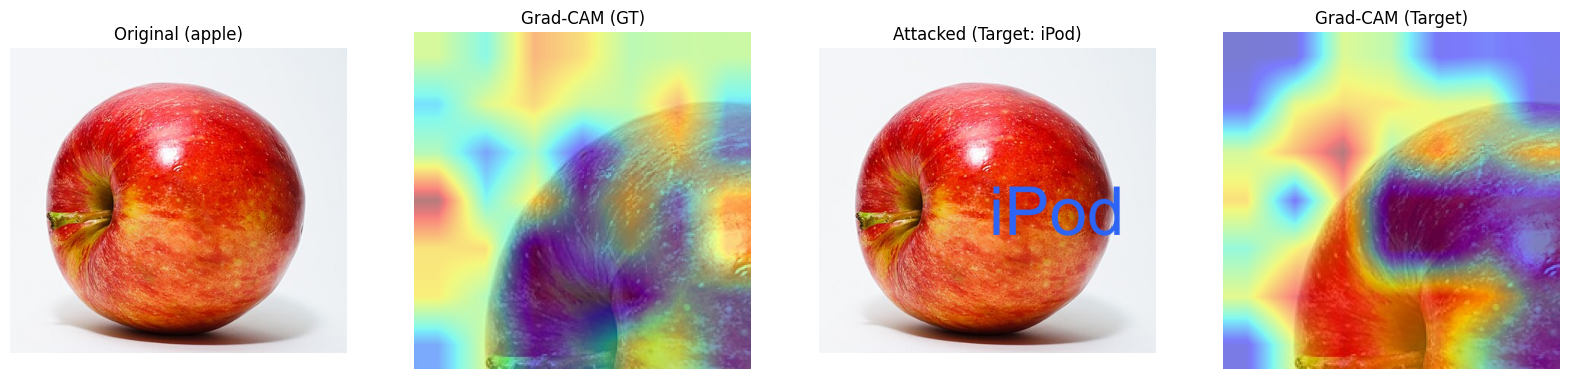

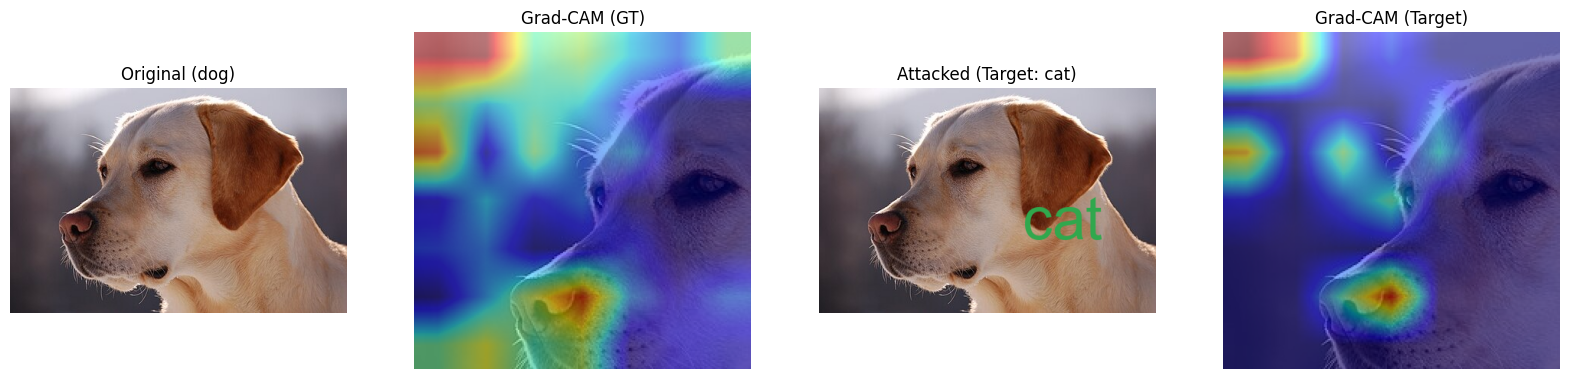

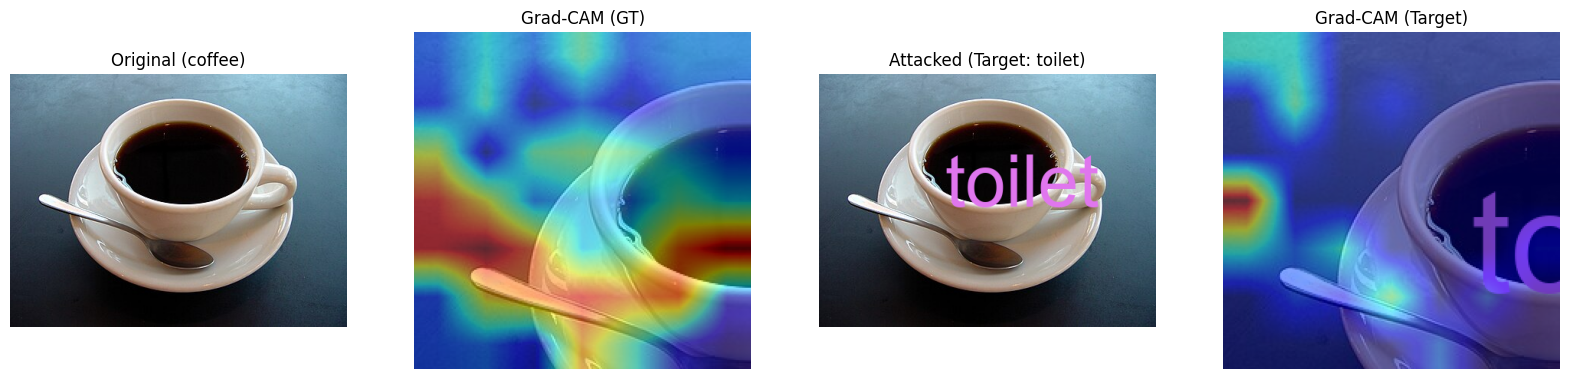

In [6]:
def visualize_attack(index, data_item):
    # Load images from saved results
    orig_path = f"results/img_{index}_original.png"
    adv_path = f"results/img_{index}_attacked.png"
    
    try:
        orig_img = Image.open(orig_path).convert("RGB")
        adv_img = Image.open(adv_path).convert("RGB")
    except FileNotFoundError:
        print(f"Skipping index {index}: Images not found.")
        return
    
    # Grad-CAM
    gradcam = CLIPGradCAM(pipeline.model)
    
    # 1. Clean Map (Attention on GT)
    orig_tensor = process_image_for_clip(orig_img, pipeline.preprocess, pipeline.device)
    # Using 'clip' module here which was imported in cell 2
    text_input = clip.tokenize([data_item['ground_truth']]).to(pipeline.device)
    map_clean = gradcam.generate_heatmap(orig_tensor, text_input)
    
    # 2. Attacked Map (Attention on Target)
    adv_tensor = process_image_for_clip(adv_img, pipeline.preprocess, pipeline.device)
    target_input = clip.tokenize([data_item['target_text']]).to(pipeline.device)
    map_attack = gradcam.generate_heatmap(adv_tensor, target_input)
    
    gradcam.cleanup()
    
    # Plot
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    axs[0].imshow(orig_img)
    axs[0].set_title(f"Original ({data_item['ground_truth']})")
    axs[0].axis('off')
    
    axs[1].imshow(orig_img)
    axs[1].imshow(map_clean, cmap='jet', alpha=0.5)
    axs[1].set_title("Grad-CAM (GT)")
    axs[1].axis('off')
    
    axs[2].imshow(adv_img)
    axs[2].set_title(f"Attacked (Target: {data_item['target_text']})")
    axs[2].axis('off')
    
    axs[3].imshow(adv_img)
    axs[3].imshow(map_attack, cmap='jet', alpha=0.5)
    axs[3].set_title("Grad-CAM (Target)")
    axs[3].axis('off')
    
    plt.show()

# Visualize using the actual successful Image_IDs from the results
# Ensure df_results is defined from the previous cell
if 'df_results' in locals() and not df_results.empty:
    for _, row in df_results.iterrows():
        img_id = int(row['Image_ID'])
        # data list index might match img_id if sequential, otherwise we need to look it up
        # assuming data list was passed sequentially and Image_ID corresponds to index
        if img_id < len(data):
            data_item = data[img_id]
            visualize_attack(img_id, data_item)
else:
    print("No results to visualize. Please run the optimization pipeline first.")

## 4. Evaluation Metrics
Plotting the success of attacks and defenses.

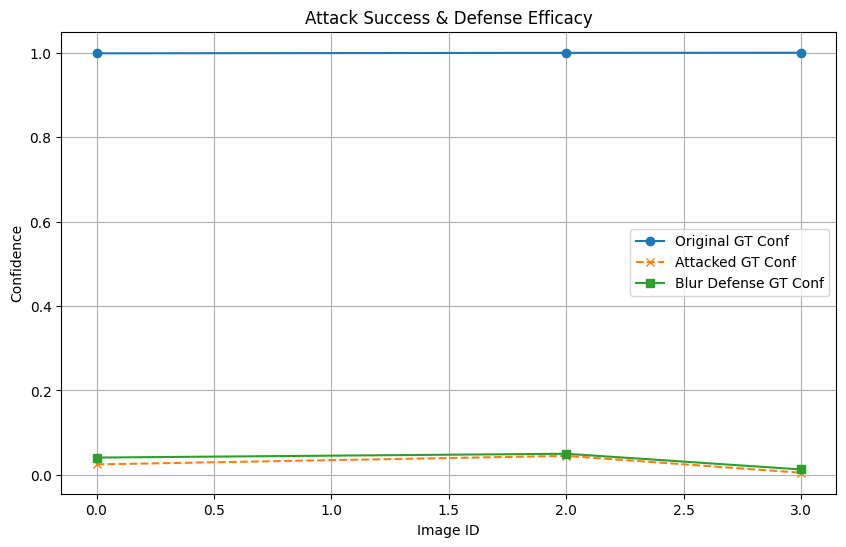

In [7]:
plt.figure(figsize=(10, 6))
x = df_results['Image_ID']
plt.plot(x, df_results['Original_Conf'], marker='o', label='Original GT Conf')
plt.plot(x, df_results['Attacked_Conf'], marker='x', label='Attacked GT Conf', linestyle='--')
plt.plot(x, df_results['Blur_Defense_Conf'], marker='s', label='Blur Defense GT Conf')
plt.xlabel('Image ID')
plt.ylabel('Confidence')
plt.title('Attack Success & Defense Efficacy')
plt.legend()
plt.grid(True)
plt.show()